Mp2 results

In [1]:
import pandas as pd
from mandelprot_lecture_4 import benchmark_mandelbrot_all

xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
width, height = 2000, 1500
max_iter = 500
chunk_rows = 64

baseline, rows = benchmark_mandelbrot_all(
    xmin,
    xmax,
    ymin,
    ymax,
    width,
    height,
    max_iter,
    chunk_rows=chunk_rows,
    process_counts=[1, 2, 4, 8],
    runs=5,
)

df = pd.DataFrame(rows)
print("Sequential baseline:", baseline)
df

Sequential baseline: 0.5809248000005027


,processes,median_time_s,min_time_s,max_time_s,speedup,efficiency
0,1,1.595411,1.552589,1.718707,0.364122,0.364122
1,2,1.245239,1.228895,1.251493,0.466517,0.233258
2,4,1.151602,1.134283,1.183512,0.504449,0.126112
3,8,1.332930,1.291599,1.346648,0.435825,0.054478


The results show that the parallel implementation was slower than the , since the speedup remained below 1.0 in every case.

A explanation could be that the sequential version was already highly optimized by Numba, so the remaining work was not large enough to offset the overhead introduced by multiprocessing.

This is consistent with the general idea behind Amdahl’s Law, where the achievable benefit from parallelism is limited by serial work and parallel overhead.

Lecture 5 results

M1 chunks = 4 time: 0.4716 s
M1 chunks = 16 time: 0.2742 s
M2 best chunk row: {'n_chunks': 64, 'time_s': 0.2510842999909073, 'min_s': 0.2456835999910254, 'max_s': 0.25808929998311214, 't1_s': 1.1431584000238217, 'speedup': 4.5528868195471395, 'LIF': 0.0}
Estimated serial fraction s: 0.04256
Tracker (1024x1024) median: 0.0744 s


,n_chunks,time_s,min_s,max_s,t1_s,speedup,LIF
0,4,0.484841,0.453775,0.504892,0.951559,1.962619,1.038093
1,8,0.335955,0.335036,0.339035,1.157154,3.444371,0.161315
2,16,0.658205,0.555023,0.681558,0.964578,1.465468,1.729504
3,32,0.655566,0.545934,0.766990,2.377419,3.626515,0.102987
4,64,0.251084,0.245684,0.258089,1.143158,4.552887,0.000000


,processes,n_chunks,time_s,min_s,max_s,speedup,ideal_speedup
0,1,64,1.019361,1.016524,1.325214,0.920847,1.0
1,2,64,0.499788,0.420386,0.513767,1.878149,2.0
2,4,64,0.292885,0.245753,0.318792,3.204929,4.0
3,8,64,0.152291,0.149321,0.177072,6.163694,8.0


,method,time_s,speedup_vs_naive
0,Naive Python,1.323689,1.000000
1,NumPy,0.501436,2.639796
2,Numba,0.031288,42.307131
3,Parallel (optimized),0.013221,100.118643


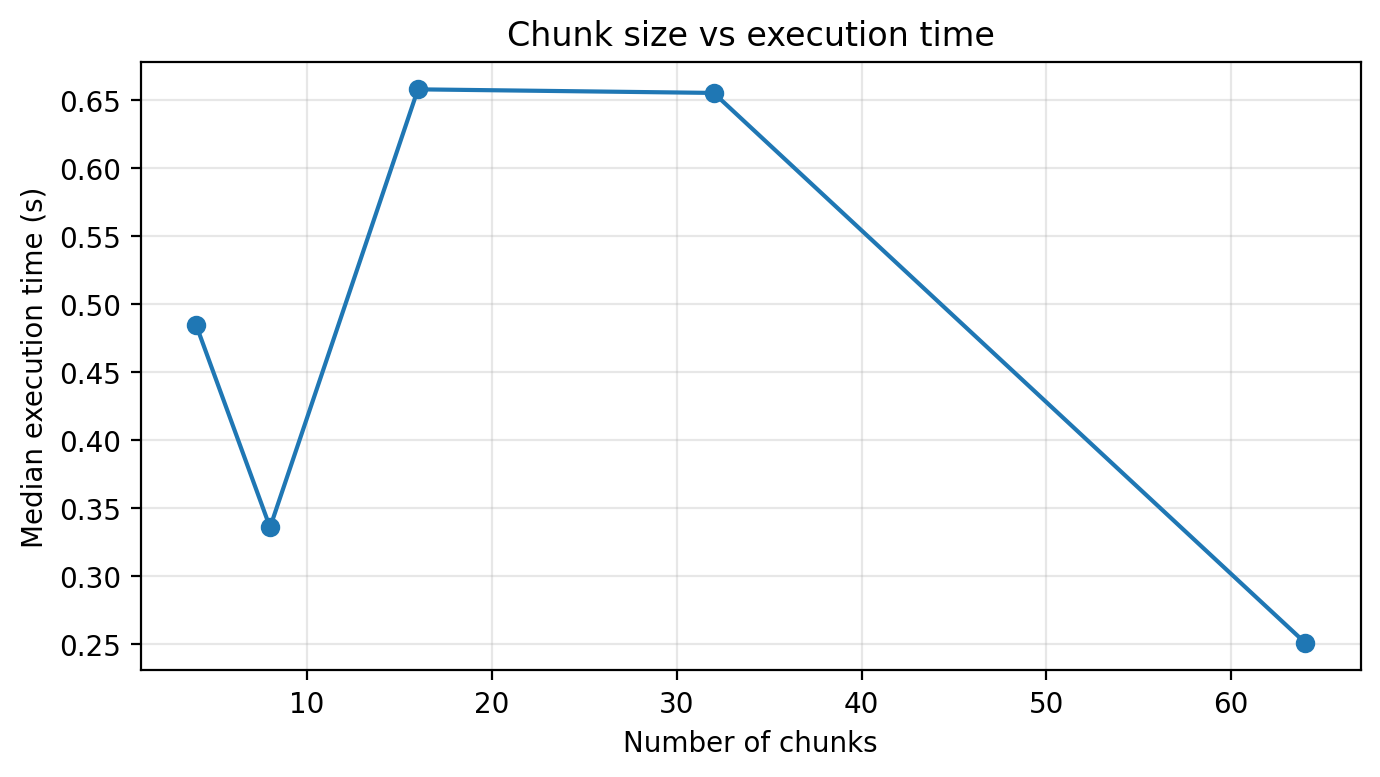

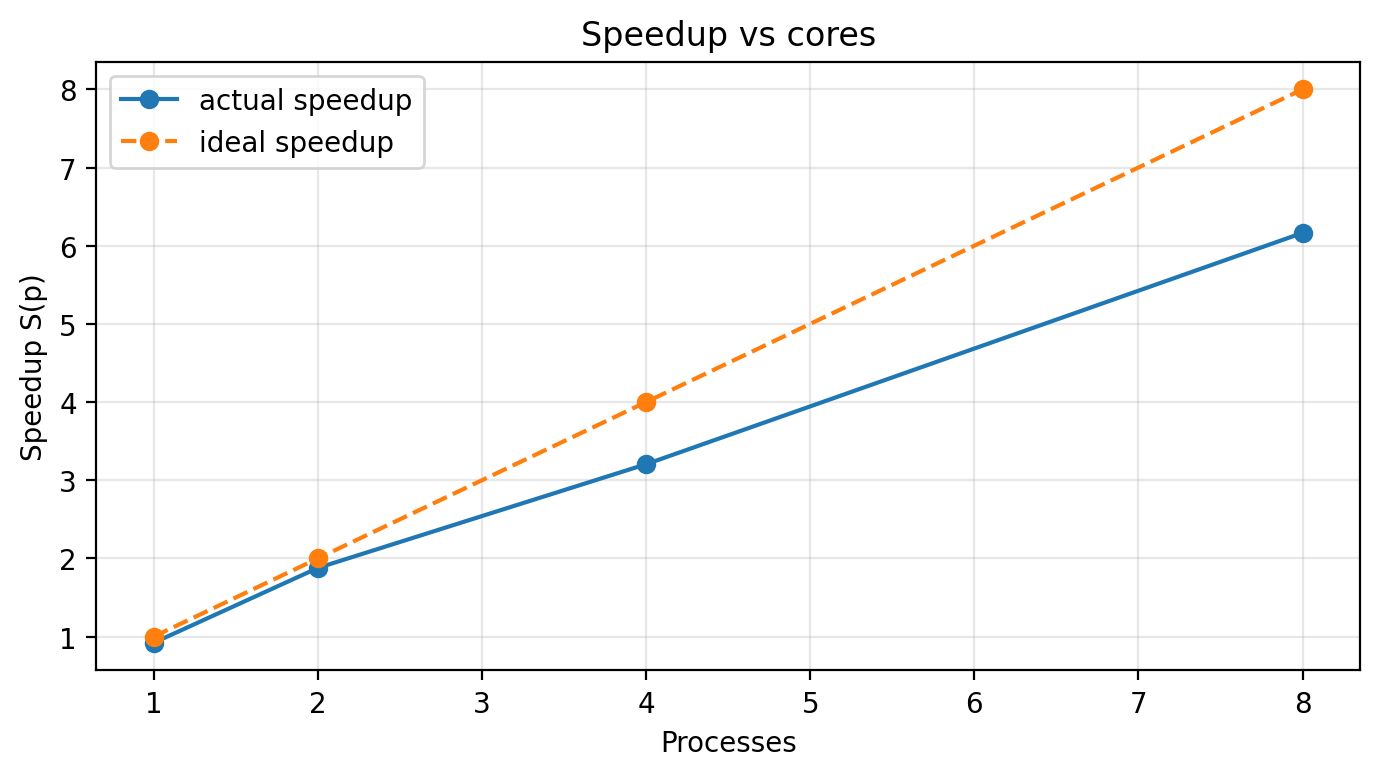

In [1]:
from IPython.display import Image, display
from mandelprot_lecture_5 import (
    plot_chunk_time,
    plot_speedup,
    run_lecture5_study,
    to_dataframes,
)

results = run_lecture5_study(
    width=2000,
    height=1500,
    max_iter=500,
    n_workers_l04=4,
    process_counts=(1, 2, 4, 8),
    runs=3,
)

chunk_df, speed_df, compare_df = to_dataframes(results)

print("M1 chunks =", results["m1_chunks_default"], "time:", round(results["m1_time_default"], 4), "s")
print("M1 chunks =", results["m1_chunks_4x"], "time:", round(results["m1_time_4x"], 4), "s")
print("M2 best chunk row:", results["best_chunk_row"])
print("Estimated serial fraction s:", round(results["serial_fraction"], 6))
print("Tracker (1024x1024) median:", round(results["tracker_1024"]["median_s"], 4), "s")

display(chunk_df)
display(speed_df)
display(compare_df)

chunk_plot_path = plot_chunk_time(results["chunk_rows"], "lecture5_chunk_time.png")
speed_plot_path = plot_speedup(results["speed_rows"], "lecture5_speedup.png")

display(Image(filename=chunk_plot_path))
display(Image(filename=speed_plot_path))


In [2]:
# Short interpretation generated from current run
best_speed_row = max(results["speed_rows"], key=lambda r: r["speedup"])
best_chunk_row = results["best_chunk_row"]

print("Interpretation")
print("- Fastest chunk setup:", best_chunk_row["n_chunks"], "chunks (LIF =", round(best_chunk_row["LIF"], 4), ")")
print("- Best speedup point:", best_speed_row["processes"], "processes with S(p)=", round(best_speed_row["speedup"], 4))
print("- Multiprocessing worth it here:", best_speed_row["speedup"] > 1.0)
print("- Why chunking helps: equal chunk sizes can still have unequal work in Mandelbrot rows.")
print("- Granularity tradeoff: too few chunks - load imbalance, too many - more overhead.")
print("- Mandelbrot is embarrassingly parallel because pixels/chunks are independent.")


Interpretation
- Fastest chunk setup: 64 chunks (LIF = 0.0 )
- Best speedup point: 8 processes with S(p)= 6.1637
- Multiprocessing worth it here: True
- Why chunking helps: equal chunk sizes can still have unequal work in Mandelbrot rows.
- Granularity tradeoff: too few chunks - load imbalance, too many - more overhead.
- Mandelbrot is embarrassingly parallel because pixels/chunks are independent.


Lecture 6 results

M1 serial time: 0.0068 s
M1 Dask time: 0.0403 s
M1 speedup vs serial: 0.1679
M2 best chunk row: {'n_chunks': 4, 'time_s': 0.028546400018967688, 'min_s': 0.028546400018967688, 'max_s': 0.028546400018967688, 't1_s': 0.029790300002787262, 'speedup': 1.0435746708163924, 'LIF': 2.8329791934014508}
M2 best LIF row: {'n_chunks': 64, 'time_s': 0.1884476999985054, 'min_s': 0.1884476999985054, 'max_s': 0.1884476999985054, 't1_s': 0.2015837999933865, 'speedup': 1.0697068735515756, 'LIF': 2.7393421496109895}
M3 Dask/MP ratio: 6.3254
Tracker path: performance_tracker.csv


,n_chunks,time_s,min_s,max_s,t1_s,speedup,LIF
0,4,0.028546,0.028546,0.028546,0.029790,1.043575,2.832979
1,8,0.038308,0.038308,0.038308,0.030710,0.801668,3.989596
2,16,0.060185,0.060185,0.060185,0.059012,0.980508,3.079516
3,32,0.248903,0.248903,0.248903,0.081895,0.329025,11.157147
4,64,0.188448,0.188448,0.188448,0.201584,1.069707,2.739342


,method,time_s,speedup_vs_naive
0,Naive Python,0.367778,1.000000
1,NumPy,0.099541,3.694725
2,Numba,0.008755,42.006339
3,Numba + multiprocessing,0.003611,101.846557
4,Dask (LocalCluster),0.022842,16.101100


,timestamp,lecture,width,height,max_iter,method,time_s,speedup_vs_naive
0,2026-04-07 19:16:36,lecture_6,256,256,120,Naive Python,0.367778,1.000000
1,2026-04-07 19:16:36,lecture_6,256,256,120,NumPy,0.099541,3.694725
2,2026-04-07 19:16:36,lecture_6,256,256,120,Numba,0.008755,42.006339
3,2026-04-07 19:16:36,lecture_6,256,256,120,Numba + multiprocessing,0.003611,101.846557
4,2026-04-07 19:16:36,lecture_6,256,256,120,Dask (LocalCluster),0.022842,16.101100


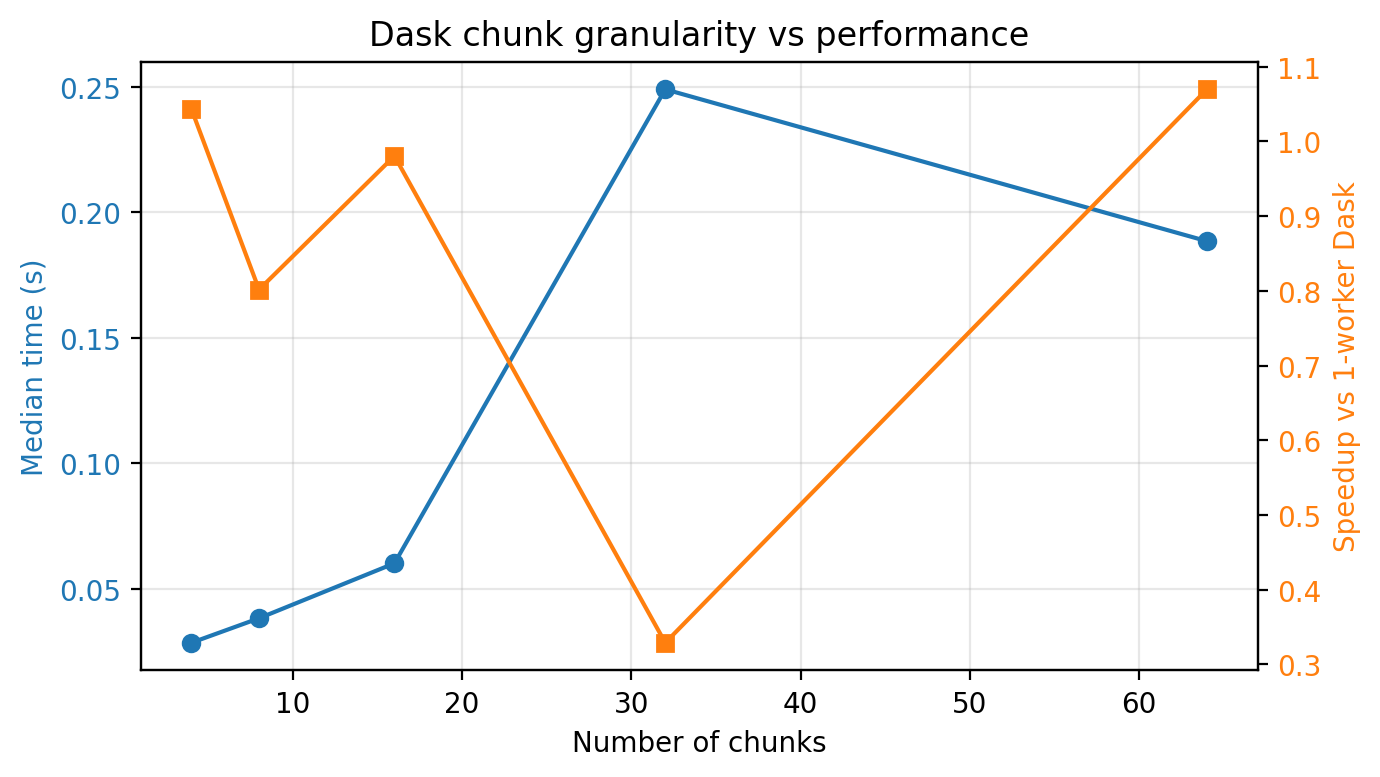

In [4]:
from IPython.display import Image, display
from mandelprot_lecture_6 import (
    plot_dask_chunk_performance,
    run_lecture6_study,
    to_dataframes,
)

results6 = run_lecture6_study(
    width=400,
    height=300,
    max_iter=120,
    n_workers=4,
    runs=1,
    comparison_width=256,
    comparison_height=256,
    comparison_max_iter=120,
    comparison_runs=1,
)

chunk6_df, compare6_df, tracker6_df = to_dataframes(results6)

print("M1 serial time:", round(results6["m1"]["serial_time_s"], 4), "s")
print("M1 Dask time:", round(results6["m1"]["dask_time_s"], 4), "s")
print("M1 speedup vs serial:", round(results6["m1"]["speedup_vs_serial"], 4))
print("M2 best chunk row:", results6["best_chunk_time_row"])
print("M2 best LIF row:", results6["best_chunk_lif_row"])
print("M3 Dask/MP ratio:", round(results6["overhead_vs_multiprocessing"]["dask_vs_mp_ratio"], 4))
print("Tracker path:", results6["tracker_path"])

display(chunk6_df)
display(compare6_df)
display(tracker6_df)

chunk6_plot_path = plot_dask_chunk_performance(
    results6["chunk_rows"],
    "lecture6_dask_chunks.png",
)
display(Image(filename=chunk6_plot_path))


In [6]:
# Short interpretation generated from current run
best_chunk_row6 = results6["best_chunk_time_row"]
overhead6 = results6["overhead_vs_multiprocessing"]

print("Interpretation")
print("- Best chunk count:", best_chunk_row6["n_chunks"])
print("- Best chunk LIF:", round(best_chunk_row6["LIF"], 4))
print("- MP time:", round(overhead6["mp_time_s"], 4), "s")
print("- Dask time:", round(overhead6["dask_time_s"], 4), "s")
print("- Dask/MP ratio:", round(overhead6["dask_vs_mp_ratio"], 4))
print("- Reflection: Dask adds scheduling overhead, while multiprocessing is lean for this chunked workload.")


Interpretation
- Best chunk count: 4
- Best chunk LIF: 2.833
- MP time: 0.0036 s
- Dask time: 0.0228 s
- Dask/MP ratio: 6.3254
- Reflection: Dask adds scheduling overhead, while multiprocessing is lean for this chunked workload.


Lecture 7 results


Cluster mode: local_emulation
Scheduler: tcp://127.0.0.1:8786
Dashboard: http://127.0.0.1:8787/status
Version check (all workers match): True
Cluster workers: 3
CPUs per VM (estimate): 1
Grid: 4096 x 4096 max_iter = 120
Numba baseline median: 1.2369 s
Best chunk row: {'n_chunks': 12, 'time_s': 0.6013587999914307, 'min_s': 0.5987129000131972, 'max_s': 0.9298298000067007}
Worker scaling rows: [{'workers': 1, 'time_s': 1.7621187999902759, 'min_s': 1.6732958999928087, 'max_s': 2.080909700016491, 'speedup_vs_1worker': 1.0, 'ideal_speedup': 1.0}, {'workers': 2, 'time_s': 0.8885377999977209, 'min_s': 0.8755214000120759, 'max_s': 0.9238192999910098, 'speedup_vs_1worker': 1.983166951360759, 'ideal_speedup': 2.0}, {'workers': 3, 'time_s': 0.7525335999962408, 'min_s': 0.7398773999884725, 'max_s': 0.8005867000028957, 'speedup_vs_1worker': 2.3415815586162245, 'ideal_speedup': 3.0}]
Speedup vs Numba baseline: 1.6436 x


,n_chunks,time_s,min_s,max_s
0,3,1.065322,1.042597,1.171230
1,6,0.747497,0.742120,0.778591
2,12,0.601359,0.598713,0.929830
3,24,0.716557,0.709297,0.737758


,workers,time_s,min_s,max_s,speedup_vs_1worker,ideal_speedup
0,1,1.762119,1.673296,2.080910,1.000000,1.0
1,2,0.888538,0.875521,0.923819,1.983167,2.0
2,3,0.752534,0.739877,0.800587,2.341582,3.0


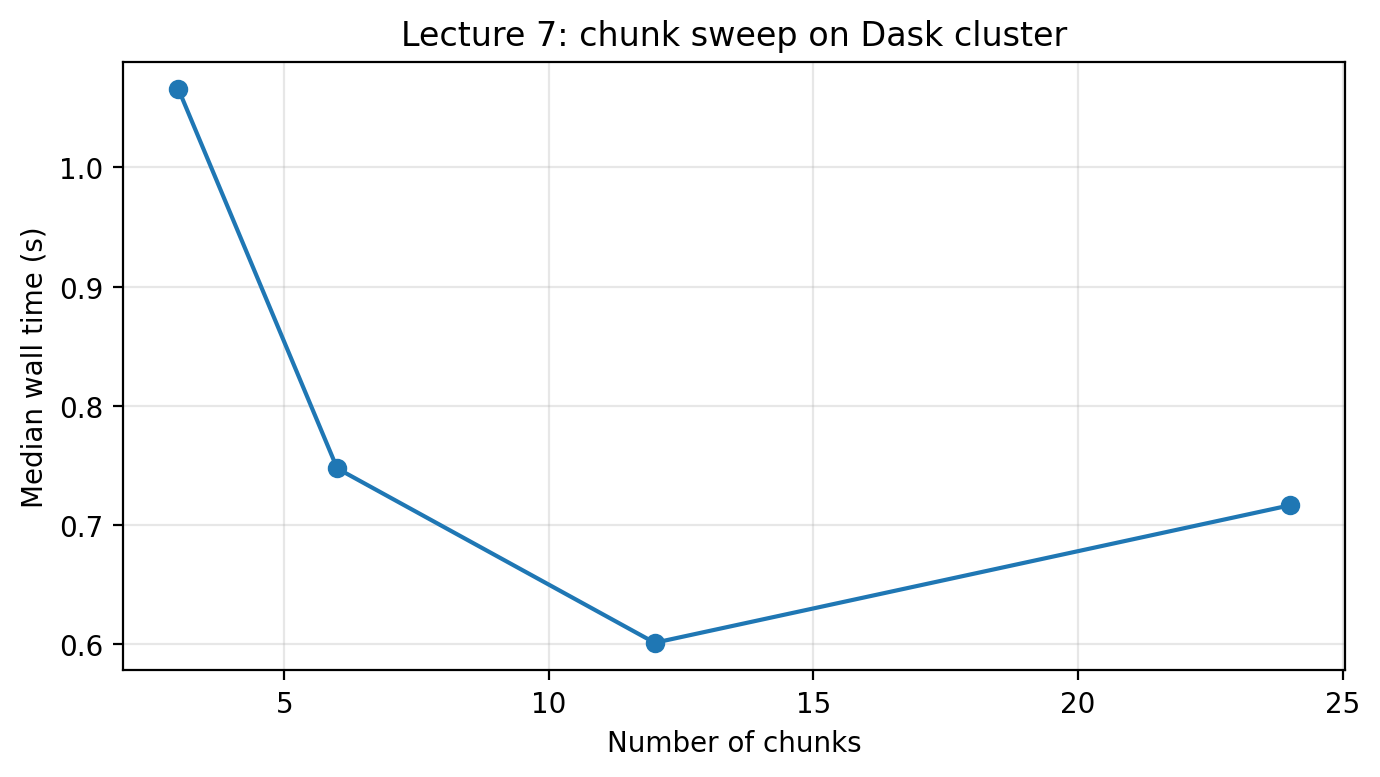

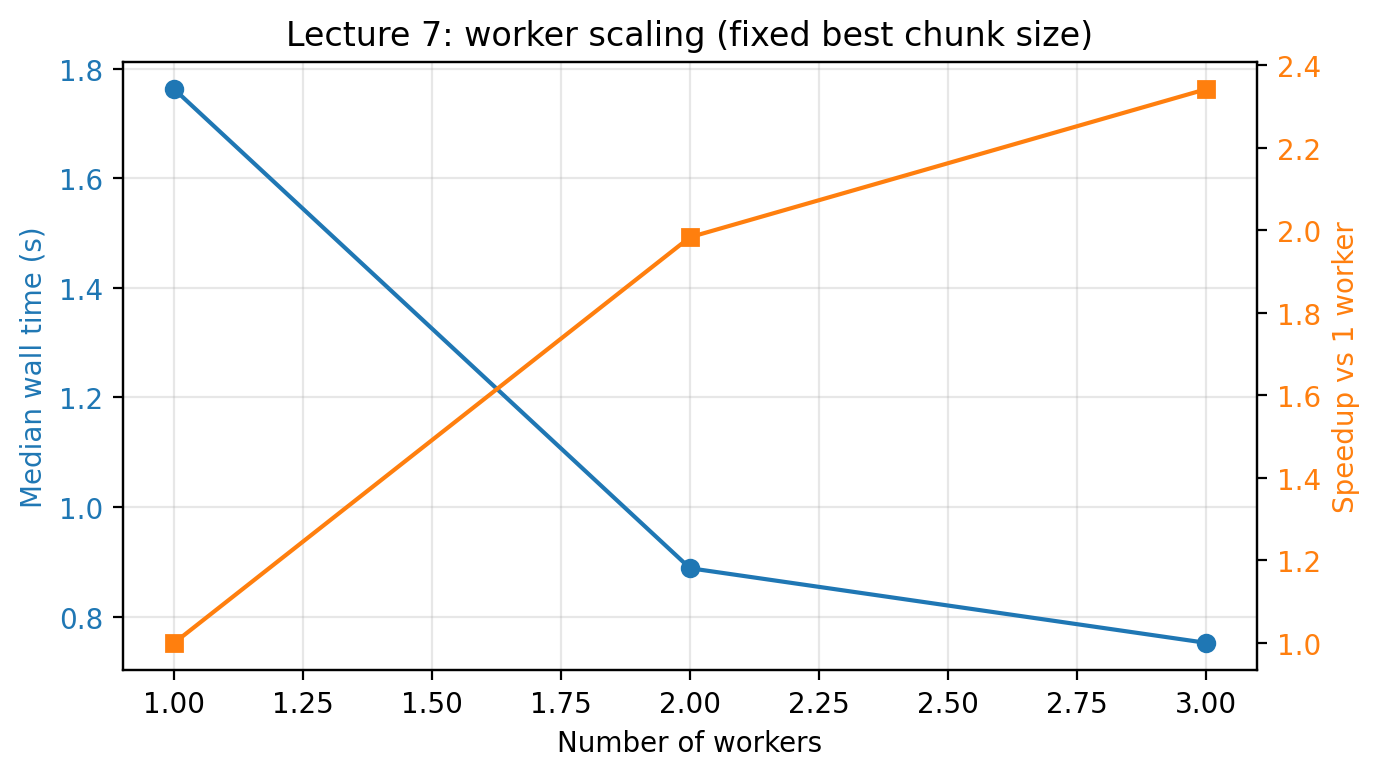

In [ ]:
from IPython.display import Image, display
from mandelprot_lecture_7 import (
    plot_chunk_sweep,
    plot_worker_scaling,
    run_lecture7_study,
    to_dataframes,
)

results7 = run_lecture7_study(
    scheduler_address="tcp://127.0.0.1:8786",  # replace with head-node IP for remote cluster
    width=4096,
    height=4096,
    max_iter=120,
    runs=3,
    chunk_multipliers=(1, 2, 4, 8),
    worker_counts=(1, 2, 3),
    launch_local_if_unreachable=True,
    local_emulation_workers=3,
    local_emulation_threads=1,
    local_emulation_scheduler_port=8786,
    local_emulation_dashboard_port=8787,
    comparison_local_workers=3,
)

chunk7_df, scaling7_df = to_dataframes(results7)


print("Version check (all workers match):", results7["version_check"]["matching_versions"])
print("Cluster workers:", results7["cluster_config"]["n_workers"])
print("CPUs per VM (estimate):", results7["cluster_config"]["cpus_per_vm_estimate"])
print("Grid:", results7["grid"]["width"], "x", results7["grid"]["height"], "max_iter =", results7["grid"]["max_iter"])
print("Numba baseline median:", round(results7["numba_baseline"]["median_s"], 4), "s")
print("Best chunk row:", results7["best_chunk_row"])
print("Worker scaling rows:", results7["worker_scaling_rows"])
print("Speedup vs Numba baseline:", round(results7["speedup_vs_numba_baseline"], 4), "x")

display(chunk7_df)
display(scaling7_df)

chunk7_plot_path = plot_chunk_sweep(results7["chunk_rows"], "lecture7_chunk_sweep.png")
scaling7_plot_path = plot_worker_scaling(results7["worker_scaling_rows"], "lecture7_worker_scaling.png")
display(Image(filename=chunk7_plot_path))
display(Image(filename=scaling7_plot_path))


Strato (Cloud VM) Pros and Cons

Pros

- Easy to scale from 1 VM to several worker VMs without changing the algorithm.
- Good match for Dask distributed experiments with real scheduler/worker networking.
- Lets you test realistic overheads (network latency, serialization, scheduling).
- Reproducible setup when VM specs are fixed (CPU count, RAM, OS image).
- Dashboard and scheduler ports (`8787` and `8786`) give clear runtime visibility.

Cons

- Setup friction is high: SSH, firewall rules, open ports, and IP handling can fail.
- Connectivity problems can block progress even when code is correct.
- Performance can vary due to shared cloud hardware and network conditions.
- Extra cost and time compared with running local experiments.
- Version mismatches across VMs can break runs if environments are not synced.
- Debugging distributed failures is harder than local multiprocessing.


I could not get strato to work from home, i kept getting and error with it saying it could not build a VM. It had an error along the lines of this: Failed to allocate the network(s) … No fixed IP addresses available for network.
So the results are from a local fallback